# Reference trajectories for van der Pol

The purpose of this notebook is narrow: **produce trajectories we can trust, save them, and
look at them.** Nothing here trains anything.

The equation, with $\mu = 1$ throughout:

$$\frac{dy_1}{dt} = y_2, \qquad \frac{dy_2}{dt} = \mu\,(1 - y_1^2)\,y_2 - y_1$$

$y_1$ is a position, $y_2$ a velocity. The damping is *negative* while $|y_1| < 1$ (energy
goes in) and positive while $|y_1| > 1$ (energy comes out). So no trajectory can settle at
rest, and none can run away — every one of them ends up circulating on the same closed loop.

**The method.** A fixed-step, seventh-stage, sixth-order explicit Runge–Kutta scheme
(`rk6.py`). Fixed step, no adaptation, no tolerances: a trajectory is reproducible to the bit.
The step is $h = 10^{-3}$, and section 2 shows that at that step the answer has stopped moving.

Code lives in `rk6.py`, `vanderpol.py`, `trajectories.py`; this notebook calls it, saves the
data to `data/`, and plots everything.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

sys.path.insert(0, str(Path.cwd()))
import rk6
import vanderpol as vdp
import trajectories as tr

FIGURES = Path.cwd() / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
CYCLE = "#e34948"      # the closed loop
INK = "#33322e"
print("van der Pol, mu =", vdp.MU)
print("integrator:", f"explicit Runge-Kutta, {rk6.N_STAGES} stages, order {rk6.ORDER}")


van der Pol, mu = 1.0
integrator: explicit Runge-Kutta, 7 stages, order 6


## 1. Is the integrator really sixth order?

The Butcher tableau is a table of coefficients typed into `rk6.py`. Two checks.

**Cheap check.** Every row of the coefficient matrix must sum to the fraction of the step at
which that stage is evaluated, and the final weights must sum to one. These catch a typo, not
a wrong method.

**Real check.** Integrate three problems whose exact answers are known, and measure how fast
the error shrinks when the step is halved. A method of order $p$ has error $\propto h^p$, so
on log axes the slope *is* the order. The three problems are chosen to be different: a linear
one, a nonlinear one, and one where the right-hand side depends on time explicitly. A linear
test alone cannot detect every possible mistake.

row sums match the stage times to 2.2e-16
final weights sum to one, error    0.0e+00
strictly lower triangular (explicit): True


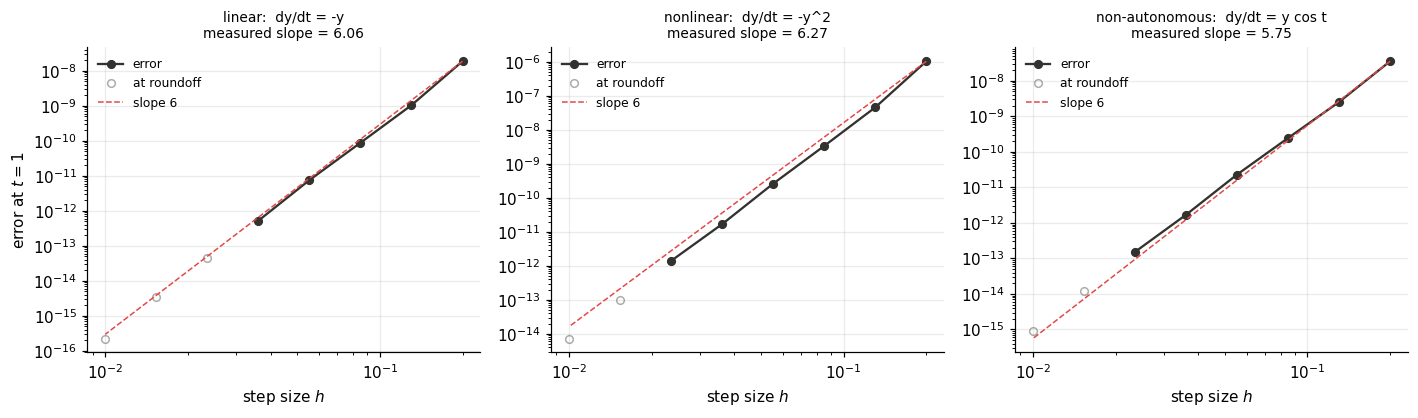

,problem,measured_order,expected
0,linear: dy/dt = -y,6.057,6
1,nonlinear: dy/dt = -y^2,6.267,6
2,non-autonomous: dy/dt = y cos t,5.748,6


In [2]:
v = rk6.verify_tableau()
print("row sums match the stage times to", f"{v['max_row_sum_error']:.1e}")
print("final weights sum to one, error   ", f"{v['weight_sum_error']:.1e}")
print("strictly lower triangular (explicit):", v["upper_triangle_max"] == 0.0)
assert v["passes"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
rows = []
for ax, (name, (f, y0, exact)) in zip(axes, rk6.TEST_PROBLEMS.items()):
    hs, errs, usable, slope = rk6.observed_order(f, y0, exact)
    ax.loglog(hs[usable], errs[usable], "o-", color=INK, ms=5, label="error")
    ax.loglog(hs[~usable], errs[~usable], "o", color=INK, ms=5, mfc="none", alpha=0.4,
              label="at roundoff")
    h0, e0 = hs[usable][0], errs[usable][0]
    ax.loglog(hs, e0 * (hs / h0) ** 6, "--", color=CYCLE, lw=1, label="slope 6")
    ax.set_title(f"{name}\nmeasured slope = {slope:.2f}", fontsize=9)
    ax.set_xlabel("step size $h$"); ax.legend(fontsize=8)
    rows.append(dict(problem=name, measured_order=round(slope, 3), expected=6))
axes[0].set_ylabel("error at $t=1$")
fig.tight_layout(); fig.savefig(FIGURES / "01_order_verification.png"); plt.show()

order = pd.DataFrame(rows)
assert (abs(order.measured_order - 6) < 0.35).all(), "the tableau is not order 6"
order

## 2. How small does the step need to be?

There is no exact solution for van der Pol to compare against, so instead: integrate with step
$h$, integrate again with step $h/2$, and see how far apart the two answers land. If the answer
is still moving, the step matters. When it stops moving, a smaller step buys nothing.

Expect the difference to fall like $h^6$ until it hits the floor set by double-precision
rounding, and then stop falling. **Where it flattens is where the step size ceases to be a
question we need to think about.**

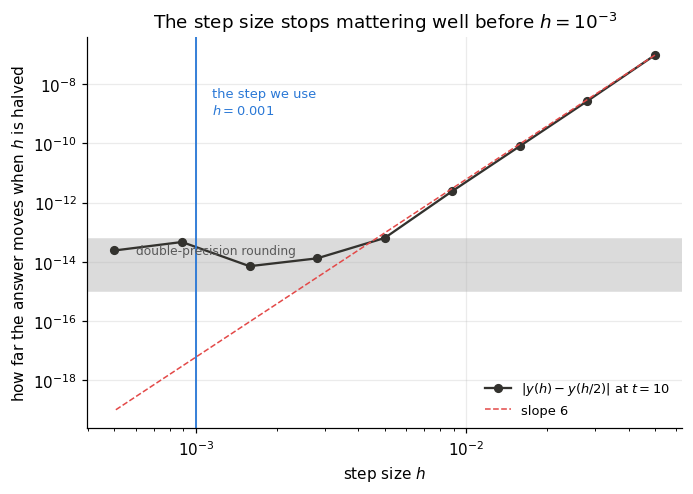

below h = 5e-3 the answer moves by at most 6.4e-14 -- that is rounding, not the scheme


,h,difference
0,0.050000,9.448242e-08
1,0.028117,2.660895e-09
2,0.015811,7.976897e-11
3,0.008891,2.415361e-12
4,0.005000,6.358729e-14
5,0.002812,1.307348e-14
6,0.001581,7.105441e-15
7,0.000889,4.648887e-14
8,0.000500,2.404897e-14


In [3]:
ss = tr.step_size_study(y0=(2.0, 0.0), t_end=10.0)

fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.loglog(ss.h, ss.difference, "o-", color=INK, ms=5, label=r"$|y(h) - y(h/2)|$ at $t=10$")
top = ss.iloc[0]
ax.loglog(ss.h, top.difference * (ss.h / top.h) ** 6, "--", color=CYCLE, lw=1,
          label="slope 6")
ax.axhspan(1e-15, 6e-14, color="0.86", zorder=0)
ax.text(6e-4, 1.8e-14, "double-precision rounding", fontsize=8, color="0.35")
ax.axvline(tr.H, color="#2a78d6", lw=1.2)
ax.text(tr.H * 1.15, 1e-9, f"the step we use\n$h = {tr.H:g}$", fontsize=8.5, color="#2a78d6")
ax.set_xlabel("step size $h$"); ax.set_ylabel("how far the answer moves when $h$ is halved")
ax.set_title("The step size stops mattering well before $h = 10^{-3}$")
ax.legend(fontsize=8.5)
fig.tight_layout(); fig.savefig(FIGURES / "02_step_size.png"); plt.show()

floor = ss[ss.h <= 5e-3].difference.max()
print(f"below h = 5e-3 the answer moves by at most {floor:.1e} -- that is rounding, not the scheme")
ss

## 3. What the equation looks like before we integrate anything

The arrows show which way a point is pushed. The two dashed curves are where each rate
vanishes:

- $dy_1/dt = 0$ on the horizontal axis;
- $dy_2/dt = 0$ on $y_2 = y_1 / \big(\mu(1 - y_1^2)\big)$, which blows up at $y_1 = \pm 1$.

They cross only at the origin, so that is the one place both rates vanish — the only
equilibrium. Both of its eigenvalues have positive real part, so it **repels**: nothing can
stay there.

eigenvalues at the origin: [0.5+0.866j 0.5-0.866j] -> real parts [0.5 0.5] (positive => repelling)


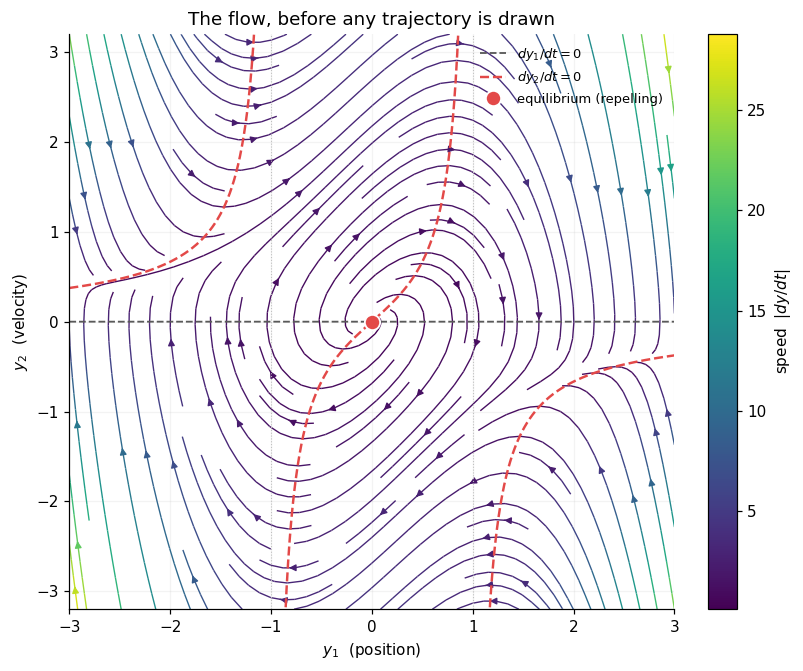

In [4]:
ev = vdp.equilibrium_eigenvalues()
print("eigenvalues at the origin:", np.round(ev, 4),
      "-> real parts", np.round(ev.real, 4), "(positive => repelling)")
assert (ev.real > 0).all()

Y1, Y2, U, V = vdp.vector_field((-3, 3), (-3.2, 3.2), n=26)
speed = np.hypot(U, V)

fig, ax = plt.subplots(figsize=(7.4, 6.2))
st = ax.streamplot(Y1, Y2, U, V, color=speed, cmap="viridis", density=1.2,
                   linewidth=0.9, arrowsize=0.9)
fig.colorbar(st.lines, ax=ax, label=r"speed  $|dy/dt|$", fraction=0.046)
g = np.linspace(-3, 3, 1600)
ax.plot(g, np.zeros_like(g), "--", color="0.35", lw=1.2, label=r"$dy_1/dt = 0$")
ax.plot(g, vdp.nullclines(g), "--", color=CYCLE, lw=1.6, label=r"$dy_2/dt = 0$")
ax.axvline(1, color="0.75", lw=0.7, ls=":"); ax.axvline(-1, color="0.75", lw=0.7, ls=":")
ax.plot(0, 0, "o", color=CYCLE, ms=10, mec="w", mew=1.2, label="equilibrium (repelling)")
ax.set_xlim(-3, 3); ax.set_ylim(-3.2, 3.2)
ax.set_xlabel("$y_1$  (position)"); ax.set_ylabel("$y_2$  (velocity)")
ax.set_title("The flow, before any trajectory is drawn")
ax.legend(fontsize=8.5, loc="upper right"); ax.grid(alpha=0.15)
fig.tight_layout(); fig.savefig(FIGURES / "03_vector_field.png"); plt.show()

## 4. Build the trajectories, and save them

Eight starting points: inside the loop, on it, outside it, and one a whisker from the
equilibrium. Each is integrated to $t = 40$ with $h = 10^{-3}$; every tenth point is kept, so
each trajectory is 4001 samples.

Written to `data/`:

- `trajectories.npz` — everything, full stored resolution. **This is what other code loads.**
- `trajectories.csv` — thinned tenfold, so the data can be eyeballed without Python.
- `initial_conditions.csv`, `metadata.csv`, `limit_cycle.csv`, `step_size_study.csv`

In [5]:
labels = list(tr.NAMED_STARTS)
y0s = np.array([tr.NAMED_STARTS[k] for k in labels])

t, Y, h_used = tr.make(y0s)
path = tr.save(t, Y, y0s, labels, h_used)

print(f"{Y.shape[1]} trajectories x {Y.shape[0]} samples, step {h_used:.1e}")
print("saved:", *sorted(p.name for p in (Path.cwd() / "data").iterdir()), sep="\n   ")
pd.read_csv("data/metadata.csv")

8 trajectories x 4001 samples, step 1.0e-03
saved:
   initial_conditions.csv
   limit_cycle.csv
   metadata.csv
   poincare_convergence.csv
   step_size_study.csv
   trajectories.csv
   trajectories.npz


,scheme,step_size,t_end,mu,n_trajectories,n_samples,stored_every
0,"explicit Runge-Kutta, 7 stages, order 6",0.001,40.0,1.0,8,4001,10


### The saved file reloads to exactly what we computed

Not a formality: if this ever fails, every downstream number is scored against the wrong
numbers.

In [6]:
t2, Y2, y02, labels2, h2, mu2 = tr.load()
print(f"max |reloaded - computed| = {np.abs(Y2 - Y).max():.1e}")
print(f"labels match: {labels2 == labels},  step matches: {h2 == h_used},  mu = {mu2}")
assert np.array_equal(Y2, Y) and labels2 == labels
print("\nthe file on disk is the trajectory, bit for bit")

max |reloaded - computed| = 0.0e+00
labels match: True,  step matches: True,  mu = 1.0

the file on disk is the trajectory, bit for bit


## 5. Every start ends on the same loop

Eight starting points, eight paths, one destination. The thick red curve is the closed loop
itself, extracted after all the transient behaviour has died away.

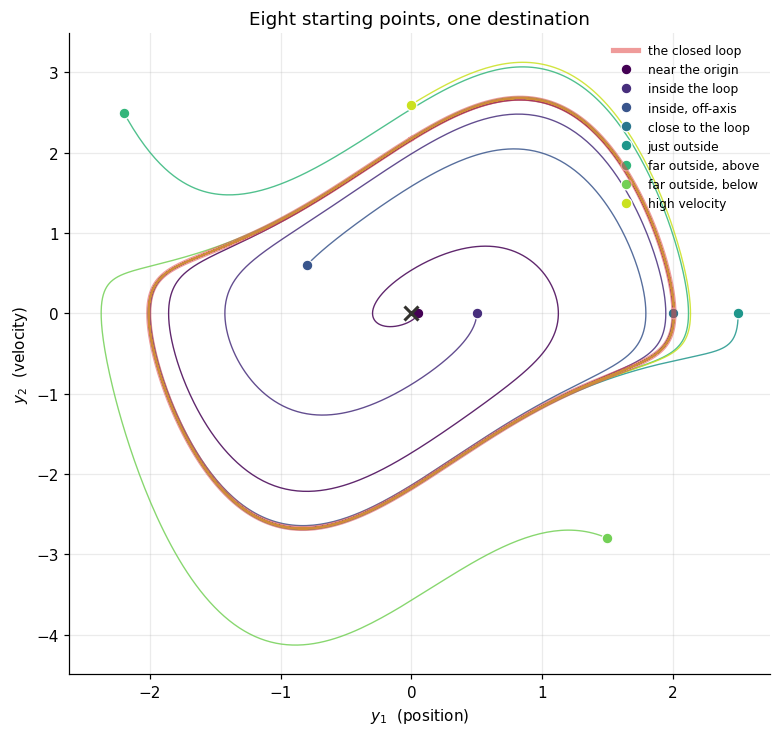

In [7]:
t_lc, Y_lc = tr.limit_cycle()

fig, ax = plt.subplots(figsize=(7.2, 6.8))
ax.plot(Y_lc[:, 0], Y_lc[:, 1], color=CYCLE, lw=3.4, alpha=0.55, zorder=6,
        label="the closed loop")
colors = cm.viridis(np.linspace(0, 0.92, len(labels)))
for k, (lab, c) in enumerate(zip(labels, colors)):
    ax.plot(Y[:, k, 0], Y[:, k, 1], lw=0.9, color=c, alpha=0.85, zorder=2)
    ax.plot(*y0s[k], "o", color=c, ms=7, mec="w", mew=0.8, zorder=3, label=lab)
ax.plot(0, 0, "x", color=INK, ms=9, mew=2, zorder=4)
ax.set_xlabel("$y_1$  (position)"); ax.set_ylabel("$y_2$  (velocity)")
ax.set_title("Eight starting points, one destination")
ax.legend(fontsize=8, loc="upper right", ncol=1)
fig.tight_layout(); fig.savefig(FIGURES / "04_phase_portrait.png"); plt.show()

### The same thing with many more starting points

A ring of starts well outside the loop, and a ring well inside it. Nothing is special about
the eight above.

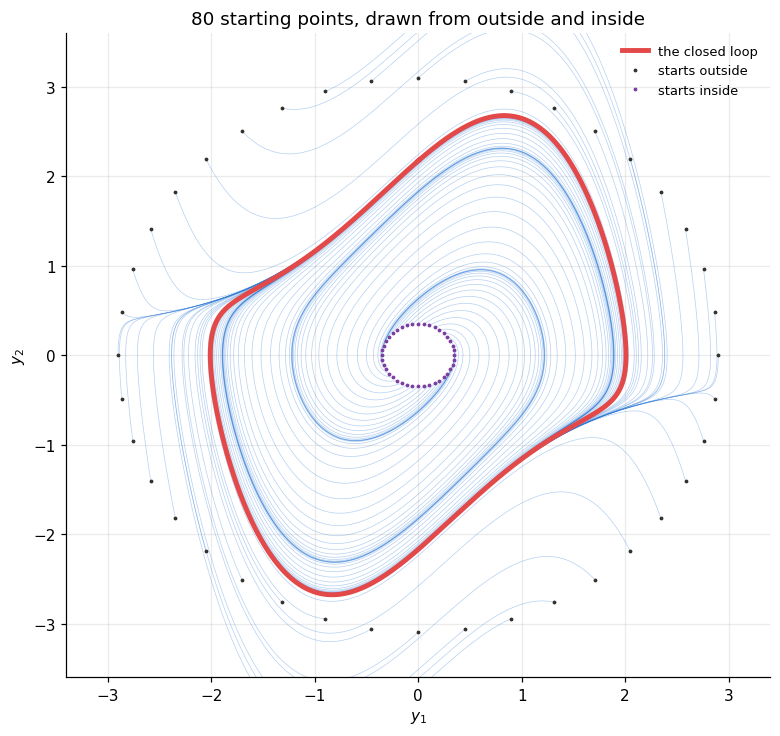

In [8]:
th = np.linspace(0, 2 * np.pi, 40, endpoint=False)
ring_out = np.stack([2.9 * np.cos(th), 3.1 * np.sin(th)], axis=1)
ring_in = np.stack([0.35 * np.cos(th), 0.35 * np.sin(th)], axis=1)
many = np.vstack([ring_out, ring_in])

t_m, Y_m, _ = tr.make(many, t_end=25.0)

fig, ax = plt.subplots(figsize=(7.2, 6.8))
for k in range(Y_m.shape[1]):
    ax.plot(Y_m[:, k, 0], Y_m[:, k, 1], lw=0.45, color="#2a78d6", alpha=0.35)
ax.plot(Y_lc[:, 0], Y_lc[:, 1], color=CYCLE, lw=3.2, zorder=3, label="the closed loop")
ax.plot(many[:40, 0], many[:40, 1], ".", color=INK, ms=3, label="starts outside")
ax.plot(many[40:, 0], many[40:, 1], ".", color="#7a3fa0", ms=3, label="starts inside")
ax.set_xlim(-3.4, 3.4); ax.set_ylim(-3.6, 3.6)
ax.set_xlabel("$y_1$"); ax.set_ylabel("$y_2$")
ax.set_title("80 starting points, drawn from outside and inside")
ax.legend(fontsize=8.5, loc="upper right")
fig.tight_layout(); fig.savefig(FIGURES / "05_many_starts.png"); plt.show()

## 6. The same trajectories, plotted against time

The phase portrait hides time. Here it is. Note how quickly the shape becomes identical from
every start — after roughly two laps you cannot tell the starts apart.

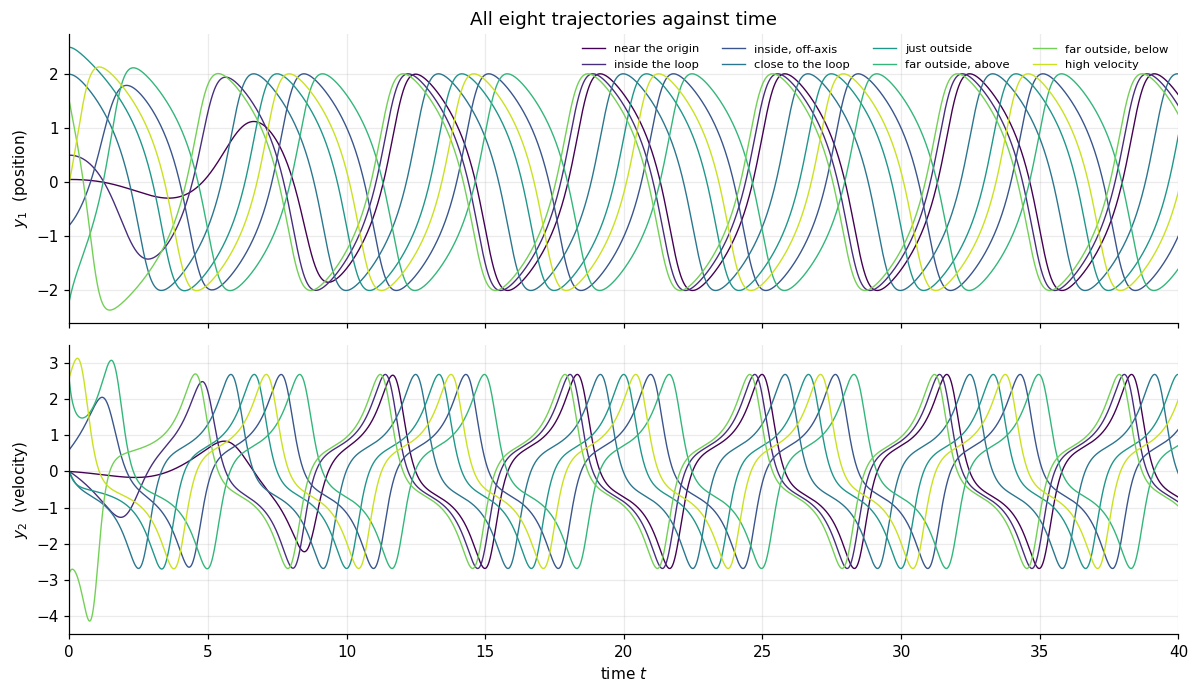

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)
for k, (lab, c) in enumerate(zip(labels, colors)):
    axes[0].plot(t, Y[:, k, 0], lw=0.9, color=c, label=lab)
    axes[1].plot(t, Y[:, k, 1], lw=0.9, color=c)
axes[0].set_ylabel("$y_1$  (position)")
axes[1].set_ylabel("$y_2$  (velocity)"); axes[1].set_xlabel("time $t$")
axes[0].set_title("All eight trajectories against time")
axes[0].legend(fontsize=7.5, ncol=4, loc="upper right")
axes[1].set_xlim(0, 40)
fig.tight_layout(); fig.savefig(FIGURES / "06_time_series.png"); plt.show()

### One trajectory, close up

Position and velocity for the start closest to the loop. The velocity spikes: the oscillator
creeps along slowly and then snaps across. That is the character van der Pol is famous for, and
it becomes far more extreme as $\mu$ grows.

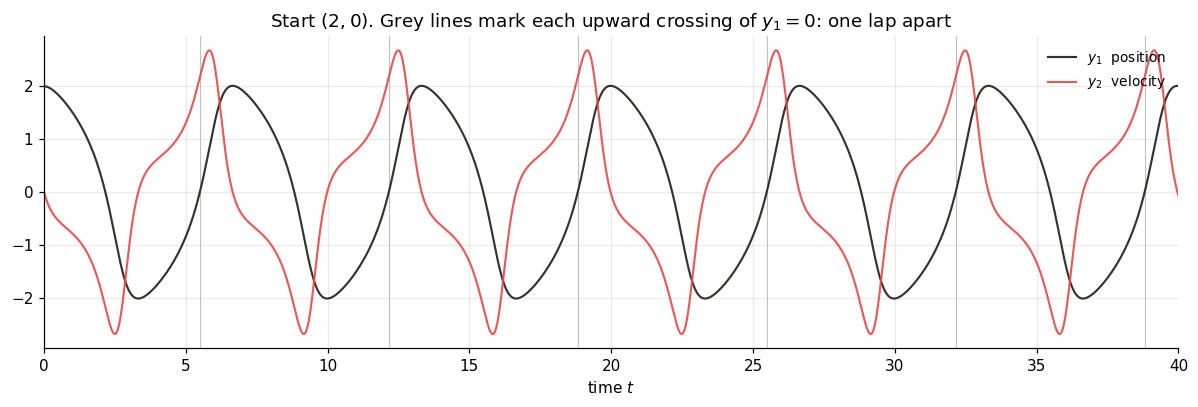

In [10]:
k = labels.index("close to the loop")
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(t, Y[:, k, 0], color=INK, lw=1.4, label="$y_1$  position")
ax.plot(t, Y[:, k, 1], color=CYCLE, lw=1.4, alpha=0.9, label="$y_2$  velocity")
cr = vdp.upward_crossings(t, Y[:, k, 0])
for c_ in cr:
    ax.axvline(c_, color="0.75", lw=0.7, zorder=0)
ax.set_xlim(0, 40); ax.set_xlabel("time $t$")
ax.set_title("Start $(2, 0)$. Grey lines mark each upward crossing of $y_1 = 0$: one lap apart")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout(); fig.savefig(FIGURES / "07_single_trajectory.png"); plt.show()

## 7. How fast does a start forget where it began?

Every time a trajectory crosses $y_1 = 0$ heading upward, record its velocity $y_2$. Once the
trajectory is on the loop, that number is the same on every lap. Off the loop, the gap to it
shrinks by a **fixed factor each lap** — that factor is a property of the loop itself, not of
the start.

> **Why not just measure the distance to the loop?** Because we only have the loop as a list of
> sampled points, spaced about $3\times10^{-3}$ apart along the curve. The distance to the
> *nearest stored point* can never fall below roughly half a spacing, so such a plot flattens
> out around $10^{-3}$ and wobbles as the trajectory slides between samples. It would be
> measuring our sampling, not the dynamics. The crossing velocity has no such problem.

The crossing time and the velocity there are found with a local cubic fit through four points,
so the interpolation error is about $h^4 = 10^{-12}$. That, and nothing else, is the floor you
see the curves land on.

velocity on the loop at y1 = 0 (upward): 2.1727136926245
last few crossings agree to 1.8e-12


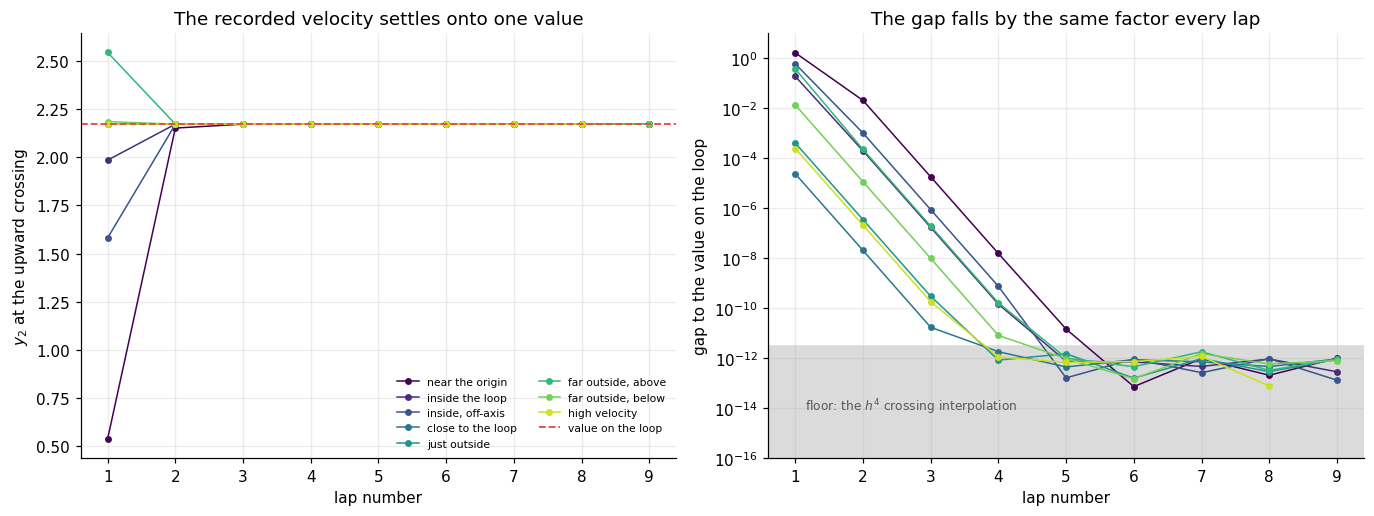


contraction per lap, measured from each start: 8.58e-04 to 8.61e-04
It is a property of the loop, so every start must agree -- and they do.


,start,per_lap_factor
0,near the origin,0.000860
1,inside the loop,0.000858
2,"inside, off-axis",0.000860
3,close to the loop,0.000860
4,just outside,0.000861
5,"far outside, above",0.000858
6,"far outside, below",0.000860
7,high velocity,0.000860


In [11]:
# a long run started ON the loop, to get the velocity the section converges to
t_on, Y_on, _ = tr.make(np.array([[2.0, 0.0]]), t_end=300.0, store_every=1)
_, v_on = vdp.poincare_section(t_on, Y_on[:, 0, 0], Y_on[:, 0, 1])
V_STAR = v_on[-1]
print(f"velocity on the loop at y1 = 0 (upward): {V_STAR:.13f}")
print(f"last few crossings agree to {np.abs(np.diff(v_on[-5:])).max():.1e}")

# every start, sampled at full resolution so the cubic fit can do its work
t_f8, Y_f8, _ = tr.make(y0s, t_end=60.0, store_every=1)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))
rows = []
for k, (lab, c) in enumerate(zip(labels, colors)):
    _, v = vdp.poincare_section(t_f8, Y_f8[:, k, 0], Y_f8[:, k, 1])
    laps = np.arange(1, len(v) + 1)
    axes[0].plot(laps, v, "o-", ms=3.5, lw=1, color=c, label=lab)
    gap = np.abs(v - V_STAR)
    axes[1].semilogy(laps, np.maximum(gap, 1e-16), "o-", ms=3.5, lw=1, color=c)
    band = (gap > 1e-10) & (gap < 1e-2)          # the straight, asymptotic part
    if band.sum() >= 2:
        g = gap[band]
        rows.append(dict(start=lab, per_lap_factor=float(np.median(g[1:] / g[:-1]))))

axes[0].axhline(V_STAR, color=CYCLE, lw=1.2, ls="--", label="value on the loop")
axes[0].set_xlabel("lap number"); axes[0].set_ylabel("$y_2$ at the upward crossing")
axes[0].set_title("The recorded velocity settles onto one value")
axes[0].legend(fontsize=7, ncol=2, loc="lower right")

axes[1].axhspan(1e-16, 3e-12, color="0.86", zorder=0)
axes[1].text(1.15, 8e-15, r"floor: the $h^4$ crossing interpolation", fontsize=8,
             color="0.35", zorder=5)
axes[1].set_xlabel("lap number"); axes[1].set_ylabel("gap to the value on the loop")
axes[1].set_title("The gap falls by the same factor every lap")
axes[1].set_ylim(1e-16, 10)
fig.tight_layout(); fig.savefig(FIGURES / "08_approach.png"); plt.show()

contraction = pd.DataFrame(rows)
contraction.to_csv("data/poincare_convergence.csv", index=False)
print(f"\ncontraction per lap, measured from each start: "
      f"{contraction.per_lap_factor.min():.2e} to {contraction.per_lap_factor.max():.2e}")
print("It is a property of the loop, so every start must agree -- and they do.")
contraction

## 8. The period of the loop

Time between successive upward crossings of $y_1 = 0$. Each gap is one lap. The first laps are
still spiralling in, so the gaps drift; once on the loop they settle to a constant.

For $\mu = 1$ the accepted value is $T \approx 6.6633$. We did not put that number in
anywhere — it falls out of the integration, which is a check on everything above.

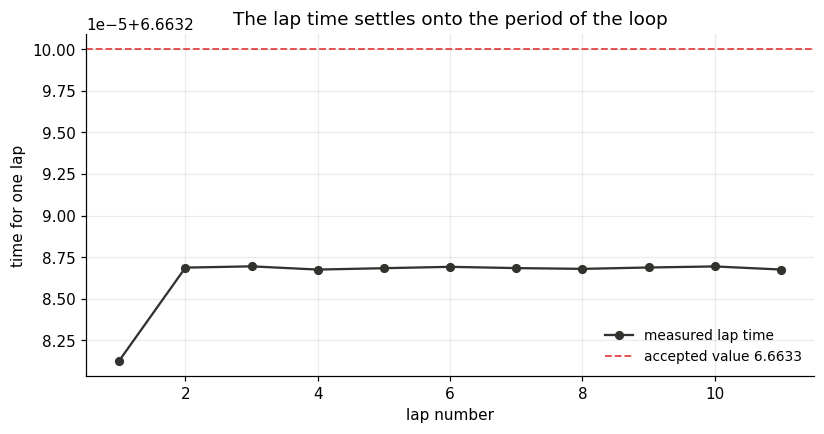

period from laps 4 onward: 6.663287  (spread 6.6e-08)
accepted value for mu = 1: 6.6633
difference:                1.53e-07


In [12]:
t_f, Y_f, _ = tr.make(np.array([[2.0, 0.0]]), t_end=80.0, store_every=1)
cr = vdp.upward_crossings(t_f, Y_f[:, 0, 0])
gaps = np.diff(cr)

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.plot(np.arange(1, len(gaps) + 1), gaps, "o-", color=INK, ms=5, label="measured lap time")
ax.axhline(6.6633, color=CYCLE, lw=1.2, ls="--", label="accepted value 6.6633")
ax.set_xlabel("lap number"); ax.set_ylabel("time for one lap")
ax.set_title("The lap time settles onto the period of the loop")
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(FIGURES / "09_period.png"); plt.show()

settled = gaps[3:]
print(f"period from laps 4 onward: {settled.mean():.6f}  (spread {settled.std():.1e})")
print(f"accepted value for mu = 1: 6.6633")
print(f"difference:                {abs(settled.mean() - 6.663287):.2e}")
assert abs(settled.mean() - 6.6633) < 1e-3, "the period does not match the accepted value"

## 9. The loop itself

Left: the closed loop, with arrows for direction and a colour showing speed — slow along the
long flanks, fast on the jumps across. Right: the same lap unrolled against time.

This curve is saved as `data/limit_cycle.csv`.

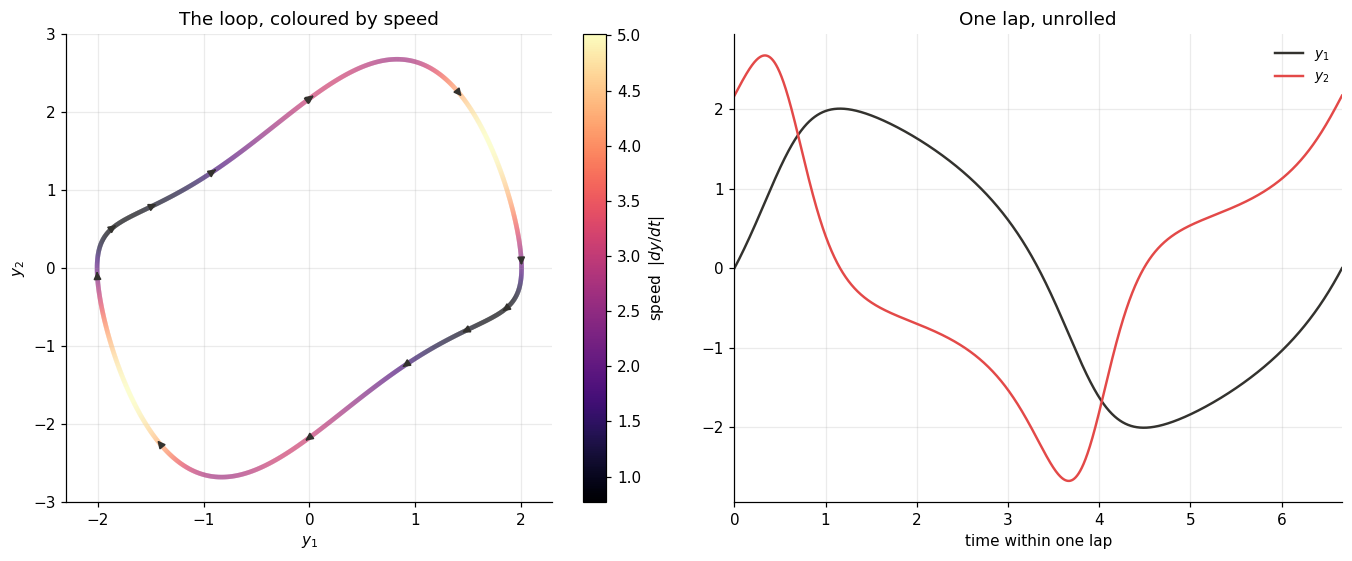

one lap lasts 6.663286859   (accepted period 6.663286859)
the loop closes: |y(T) - y(0)| = 5.6e-14
loop extent: |y1| <= 2.0086,  |y2| <= 2.6784


In [13]:
sp = np.linalg.norm(vdp.f(0.0, Y_lc), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))
ax = axes[0]
pts = Y_lc.reshape(-1, 1, 2)
from matplotlib.collections import LineCollection
seg = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc_col = LineCollection(seg, cmap="magma", norm=plt.Normalize(sp.min(), sp.max()), lw=3)
lc_col.set_array(sp[:-1]); ax.add_collection(lc_col)
n_lc = len(Y_lc)
for i in range(0, n_lc, n_lc // 12):          # the lap is closed, so wrap the index
    ax.annotate("", xy=Y_lc[(i + 30) % n_lc], xytext=Y_lc[i],
                arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.1))
ax.set_xlim(-2.3, 2.3); ax.set_ylim(-3.0, 3.0)
ax.set_xlabel("$y_1$"); ax.set_ylabel("$y_2$"); ax.set_title("The loop, coloured by speed")
fig.colorbar(lc_col, ax=ax, label="speed  $|dy/dt|$")

ax = axes[1]
ax.plot(t_lc, Y_lc[:, 0], color=INK, lw=1.6, label="$y_1$")
ax.plot(t_lc, Y_lc[:, 1], color=CYCLE, lw=1.6, label="$y_2$")
ax.set_xlabel("time within one lap"); ax.set_title("One lap, unrolled")
ax.legend(fontsize=9); ax.set_xlim(0, t_lc[-1])
fig.tight_layout(); fig.savefig(FIGURES / "10_limit_cycle.png"); plt.show()

print(f"one lap lasts {t_lc[-1]:.9f}   (accepted period 6.663286859)")
print(f"the loop closes: |y(T) - y(0)| = {np.linalg.norm(Y_lc[-1] - Y_lc[0]):.1e}")
assert np.linalg.norm(Y_lc[-1] - Y_lc[0]) < 1e-9, "the saved loop does not close"
print(f"loop extent: |y1| <= {np.abs(Y_lc[:,0]).max():.4f},  |y2| <= {np.abs(Y_lc[:,1]).max():.4f}")

## What we have now

`data/trajectories.npz` holds eight trajectories from eight starting points, integrated with a
fixed-step sixth-order Runge–Kutta scheme at $h = 10^{-3}$, out to $t = 40$, at $\mu = 1$.
Reloading it returns exactly what was computed.

Three independent things say the integration is right, and none of them was put in by hand:

1. the scheme reproduces its stated order, 6, on three problems with known exact solutions;
2. halving the step stops changing the answer below $h \approx 5 \times 10^{-3}$, at the level
   of double-precision rounding;
3. the period of the loop comes out at the accepted value for $\mu = 1$.

That is the whole reference. Nothing else about it needs deciding.

In [14]:
summary = pd.DataFrame([
    dict(check="order of the scheme, measured on 3 exact problems",
         value=f"{order.measured_order.min():.2f} - {order.measured_order.max():.2f}",
         expected="6"),
    dict(check="answer moves when h is halved (h <= 5e-3)",
         value=f"{floor:.1e}", expected="rounding, ~1e-14"),
    dict(check="period of the loop", value=f"{settled.mean():.6f}", expected="6.6633"),
    dict(check="saved file reloads identically", value="exact", expected="exact"),
    dict(check="contraction onto the loop, per lap",
         value=f"{contraction.per_lap_factor.median():.2e}",
         expected="same from every start"),
])
summary

,check,value,expected
0,"order of the scheme, measured on 3 exact problems",5.75 - 6.27,6
1,answer moves when h is halved (h <= 5e-3),6.4e-14,"rounding, ~1e-14"
2,period of the loop,6.663287,6.6633
3,saved file reloads identically,exact,exact
4,"contraction onto the loop, per lap",8.60e-04,same from every start
